# EV Adoption Analysis in Ireland

This project aims to analyse and predict electric vehicle adoption trends based on factors such as fuel prices, incentives, and technological advancements.

In [16]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
print("Environment setup complete")

Environment setup complete


In [18]:
# Check versions 
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.2.2
Numpy version: 1.26.4


In [19]:
# Load datasets

ev_df = pd.read_excel('EVDataExplorer2025.xlsx')

fuel_df = pd.read_csv('CPM12.20260312T150355.csv')

transport_df = pd.read_csv('TEM12.20260312T150343.csv')

# Exploring the EV sales dataset

In [21]:
# Preview EV dataset
ev_df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [22]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  object 
 1   category         16436 non-null  object 
 2   parameter        16436 non-null  object 
 3   mode             16436 non-null  object 
 4   powertrain       16436 non-null  object 
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  object 
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB


In [23]:
ev_df.describe()

,year,value
count,16436.000000,1.643600e+04
mean,2018.852336,2.678267e+05
std,4.271488,3.325613e+06
min,2010.000000,1.200000e-06
25%,2016.000000,1.000000e+00
50%,2019.000000,4.900000e+01
75%,2022.000000,2.500000e+03
max,2030.000000,1.700000e+08


In [24]:
ev_df.isnull().sum()

region_country     0
category           0
parameter          0
mode               0
powertrain         0
year               0
unit               0
value              0
Aggregate group    0
dtype: int64

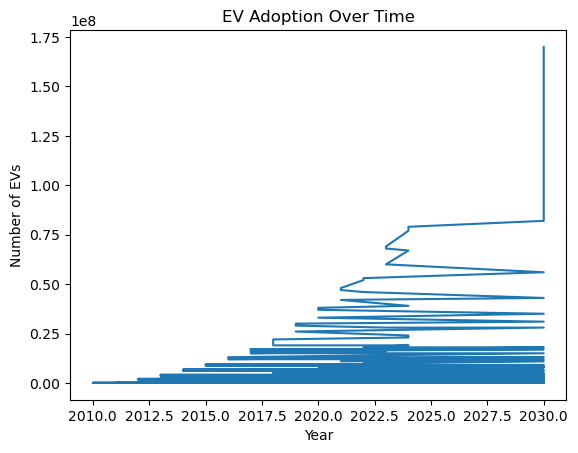

In [25]:
plt.plot(ev_df['year'], ev_df['value'])
plt.title('EV Adoption Over Time')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.show()

In [26]:
ireland_ev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV stock') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

In [27]:
ireland_ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group


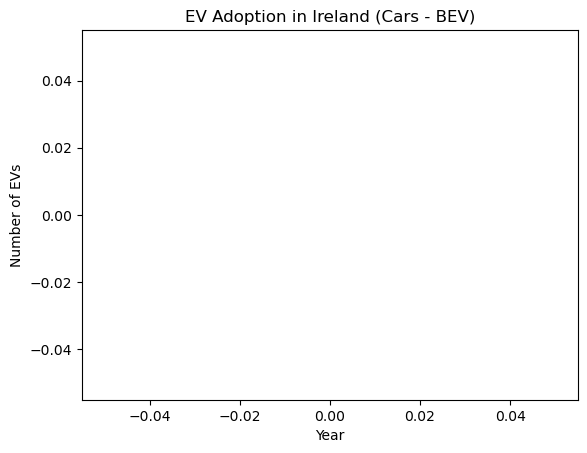

In [28]:
plt.plot(ireland_ev['year'], ireland_ev['value'])
plt.title('EV Adoption in Ireland (Cars - BEV)')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.show()

In [29]:
ev_df['region_country'].unique()

array(['World', 'China', 'Asia Pacific', 'India', 'Europe',
       'Rest of the world', 'USA', 'EU27', 'North America', 'Germany',
       'Viet Nam', 'United Kingdom', 'France', 'Norway', 'Canada',
       'Netherlands', 'Central and South America', 'Korea', 'Indonesia',
       'Sweden', 'Belgium', 'Denmark', 'Japan', 'Italy', 'Australia',
       'Turkiye', 'Spain', 'Switzerland', 'Austria', 'Israel', 'Thailand',
       'Finland', 'Portugal', 'Brazil', 'New Zealand',
       'Middle East and Caspian', 'Poland', 'Mexico', 'Malaysia',
       'Russia', 'Iceland', 'Greece', 'Uzbekistan', 'Africa', 'Ireland',
       'Chile', 'Costa Rica', 'Colombia', 'Romania', 'Luxembourg',
       'Czech Republic', 'Hungary', 'Slovenia', 'South Africa',
       'Slovakia', 'Lithuania', 'Bulgaria', 'Croatia', 'Latvia',
       'Estonia', 'Cyprus', 'Jordan', 'Seychelles'], dtype=object)

In [30]:
ev_df['parameter'].unique()

array(['EV stock', 'EV sales', 'EV charging points', 'Electricity demand',
       'Oil displacement, million lge', 'Battery demand',
       'EV sales share', 'EV stock share', 'Oil displacement Mbd'],
      dtype=object)

In [31]:
ev_df['mode'].unique()

array(['2 and 3 wheelers', 'Cars', 'Vans', 'EV', 'Trucks', 'Buses'],
      dtype=object)

In [32]:
ev_df['powertrain'].unique()

array(['BEV', 'PHEV', 'Publicly available slow',
       'Publicly available fast', 'EV', 'FCEV'], dtype=object)

In [33]:
ireland_data = ev_df[ev_df['region_country'] == 'Ireland']
ireland_data.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
2063,Ireland,Historical,EV sales,Cars,BEV,2023,Vehicles,23000.0,Other
2284,Ireland,Historical,EV sales,Cars,BEV,2024,Vehicles,17000.0,Other
2334,Ireland,Historical,EV sales,Cars,BEV,2022,Vehicles,16000.0,Other
2495,Ireland,Historical,EV sales,Cars,PHEV,2024,Vehicles,13000.0,Other
2704,Ireland,Historical,EV sales,Cars,PHEV,2023,Vehicles,10000.0,Other


In [34]:
ireland_data['parameter'].unique()

array(['EV sales', 'EV sales share'], dtype=object)

In [35]:
ireland_data['mode'].unique()

array(['Cars'], dtype=object)

In [36]:
ireland_data['powertrain'].unique()

array(['BEV', 'PHEV', 'EV'], dtype=object)

In [37]:
ireland_ev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

In [38]:
ireland_ev = ireland_ev.sort_values(by='year')

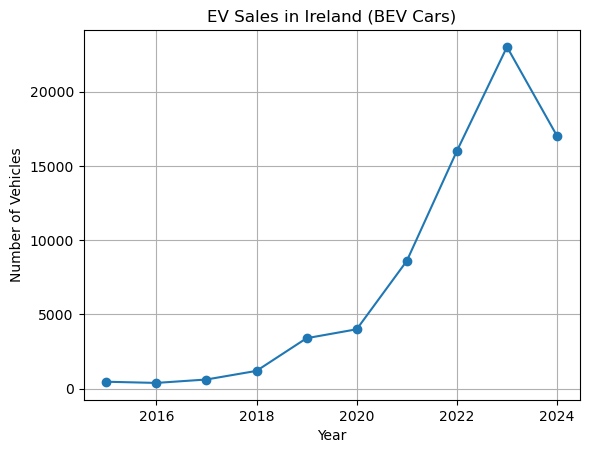

In [39]:
plt.plot(ireland_ev['year'], ireland_ev['value'], marker='o')
plt.title('EV Sales in Ireland (BEV Cars)')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles')
plt.grid()
plt.show()

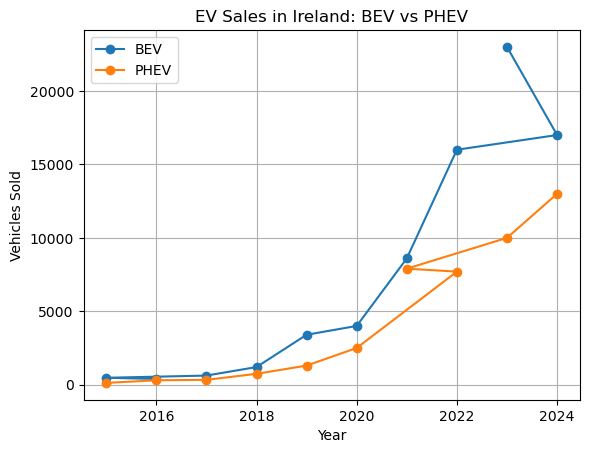

In [40]:
bev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

phev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'PHEV')
]

plt.plot(bev['year'], bev['value'], marker='o', label='BEV')
plt.plot(phev['year'], phev['value'], marker='o', label='PHEV')

plt.title('EV Sales in Ireland: BEV vs PHEV')
plt.xlabel('Year')
plt.ylabel('Vehicles Sold')
plt.legend()
plt.grid()
plt.show()

In [41]:
ireland_ev = ireland_ev.sort_values(by='year')

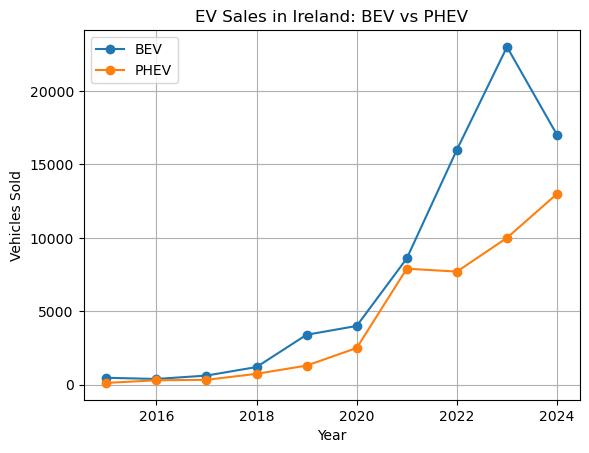

Text(0.5, 1.0, 'Comparison of BEV and PHEV Adoption in Ireland (2015–2024)')

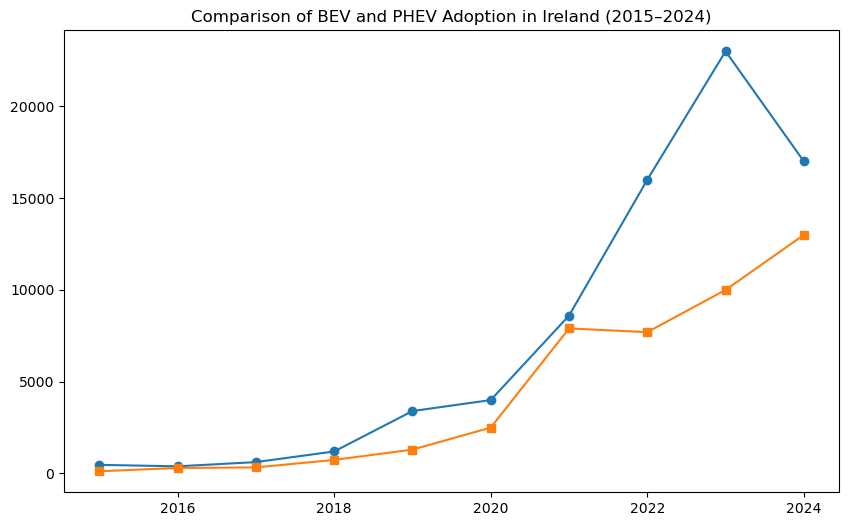

In [42]:
bev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

phev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'PHEV')
]

bev = bev.sort_values(by='year')
phev = phev.sort_values(by='year')

plt.plot(bev['year'], bev['value'], marker='o', label='BEV')
plt.plot(phev['year'], phev['value'], marker='o', label='PHEV')

plt.title('EV Sales in Ireland: BEV vs PHEV')
plt.xlabel('Year')
plt.ylabel('Vehicles Sold')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(bev['year'], bev['value'], marker='o', label='BEV')
plt.plot(phev['year'], phev['value'], marker='s', label='PHEV')
plt.title('Comparison of BEV and PHEV Adoption in Ireland (2015–2024)')

## EV Adoption Trends in Ireland (BEV vs PHEV)

The graph above illustrates the growth in electric vehicle adoption in Ireland between 2015 and 2024, comparing Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs).

From the data, it is evident that BEVs have experienced significantly faster growth, particularly after 2020, indicating a shift towards fully electric vehicles. While PHEVs have also increased over time, their growth has been more gradual, suggesting they may serve as a transitional technology rather than a long-term solution.

A noticeable decline in BEV sales is observed in 2024, which may be attributed to external factors such as changes in government incentives, economic conditions, or supply constraints. This highlights the importance of considering external variables when analysing EV adoption trends.

Overall, the data demonstrates a strong upward trend in EV adoption in Ireland, supporting the argument that electric vehicles are becoming increasingly mainstream.## EV Adoption Trends in Ireland (BEV vs PHEV)

The graph above illustrates the growth in electric vehicle adoption in Ireland between 2015 and 2024, comparing Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs).

From the data, it is evident that BEVs have experienced significantly faster growth, particularly after 2020, indicating a shift towards fully electric vehicles. While PHEVs have also increased over time, their growth has been more gradual, suggesting they may serve as a transitional technology rather than a long-term solution.

A noticeable decline in BEV sales is observed in 2024, which may be attributed to external factors such as changes in government incentives, economic conditions, or supply constraints. This highlights the importance of considering external variables when analysing EV adoption trends.

Overall, the data demonstrates a strong upward trend in EV adoption in Ireland, supporting the argument that electric vehicles are becoming increasingly mainstream.

## Fuel Prices Dataset Exploration

In [45]:
fuel_df.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
0,National Average Price,2011 December,"White, self raising flour per 2 kg",Euro,NaN
1,National Average Price,2011 December,"Brown, wholemeal flour per 2 kg",Euro,NaN
2,National Average Price,2011 December,"Bread, white sliced pan, large (800g)",Euro,NaN
3,National Average Price,2011 December,"Bread, brown sliced pan, large (800g)",Euro,NaN
4,National Average Price,2011 December,Spaghetti per 500g,Euro,NaN


In [46]:
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12996 entries, 0 to 12995
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC Label  12996 non-null  object 
 1   Month            12996 non-null  object 
 2   Consumer Item    12996 non-null  object 
 3   UNIT             12996 non-null  object 
 4   VALUE            11679 non-null  float64
dtypes: float64(1), object(4)
memory usage: 507.8+ KB


In [47]:
fuel_df.describe()

,VALUE
count,11679.000000
mean,8.407206
std,8.783095
min,0.767000
25%,2.065000
50%,5.037000
75%,11.591500
max,57.321000


In [48]:
fuel_df.isnull().sum()

STATISTIC Label       0
Month                 0
Consumer Item         0
UNIT                  0
VALUE              1317
dtype: int64

In [49]:
fuel_df.columns

Index(['STATISTIC Label', 'Month', 'Consumer Item', 'UNIT', 'VALUE'], dtype='object')

In [50]:
fuel_df.head(10)

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
0,National Average Price,2011 December,"White, self raising flour per 2 kg",Euro,NaN
1,National Average Price,2011 December,"Brown, wholemeal flour per 2 kg",Euro,NaN
2,National Average Price,2011 December,"Bread, white sliced pan, large (800g)",Euro,NaN
3,National Average Price,2011 December,"Bread, brown sliced pan, large (800g)",Euro,NaN
4,National Average Price,2011 December,Spaghetti per 500g,Euro,NaN
5,National Average Price,2011 December,Sirloin steak per kg,Euro,NaN
6,National Average Price,2011 December,Striploin steak per kg,Euro,NaN
7,National Average Price,2011 December,Roast beef - topside or rib per kg,Euro,NaN
8,National Average Price,2011 December,Sliced / diced beef pieces per kg,Euro,NaN
9,National Average Price,2011 December,Pork loin chops per kg,Euro,NaN


In [51]:
fuel_df['Consumer Item'].unique()

array(['White, self raising flour per 2 kg',
       'Brown, wholemeal flour per 2 kg',
       'Bread, white sliced pan, large (800g)',
       'Bread, brown sliced pan, large (800g)', 'Spaghetti per 500g',
       'Sirloin steak per kg', 'Striploin steak per kg',
       'Roast beef - topside or rib per kg',
       'Sliced / diced beef pieces per kg', 'Pork loin chops per kg',
       'Pork steak per kg', 'Lamb - whole leg / half leg per kg',
       'Lamb loin chops per kg', 'Lamb gigot chops per kg',
       'Uncooked chicken medium size 1.6kg', "Lamb's liver per kg",
       'Ham fillet per kg', 'Cooked ham per kg',
       'Best back rashers per kg', 'Pork sausages per kg',
       'Fresh fillet of whiting per kg', 'Fresh fillet of cod per kg',
       'Fresh salmon per kg', 'Fresh fillet of plaice per kg',
       'Fresh hake per kg', 'Smoked salmon per kg',
       'Full fat milk per 2 litre', 'Low fat milk per 1 litre',
       'Irish cheddar per kg', 'Large eggs per half dozen',
       'Med

In [52]:
fuel_prices = fuel_df[
    fuel_df['Consumer Item'].str.contains('petrol|diesel|fuel', case=False, na=False)
]

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
69,National Average Price,2011 December,Diesel per litre,Euro,NaN
70,National Average Price,2011 December,Petrol - unleaded per litre,Euro,NaN
145,National Average Price,2012 January,Diesel per litre,Euro,1.529
146,National Average Price,2012 January,Petrol - unleaded per litre,Euro,1.542
221,National Average Price,2012 February,Diesel per litre,Euro,1.554


In [53]:
fuel_prices = fuel_df[
    fuel_df['Consumer Item'].str.contains('petrol|diesel|fuel', case=False, na=False)
].copy()

fuel_prices['Month'] = pd.to_datetime(fuel_prices['Month'], format='%Y %B')
fuel_prices['year'] = fuel_prices['Month'].dt.year

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE,year
69,National Average Price,2011-12-01,Diesel per litre,Euro,NaN,2011
70,National Average Price,2011-12-01,Petrol - unleaded per litre,Euro,NaN,2011
145,National Average Price,2012-01-01,Diesel per litre,Euro,1.529,2012
146,National Average Price,2012-01-01,Petrol - unleaded per litre,Euro,1.542,2012
221,National Average Price,2012-02-01,Diesel per litre,Euro,1.554,2012


In [54]:
petrol = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('petrol', case=False, na=False)
]

diesel = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('diesel', case=False, na=False)
]

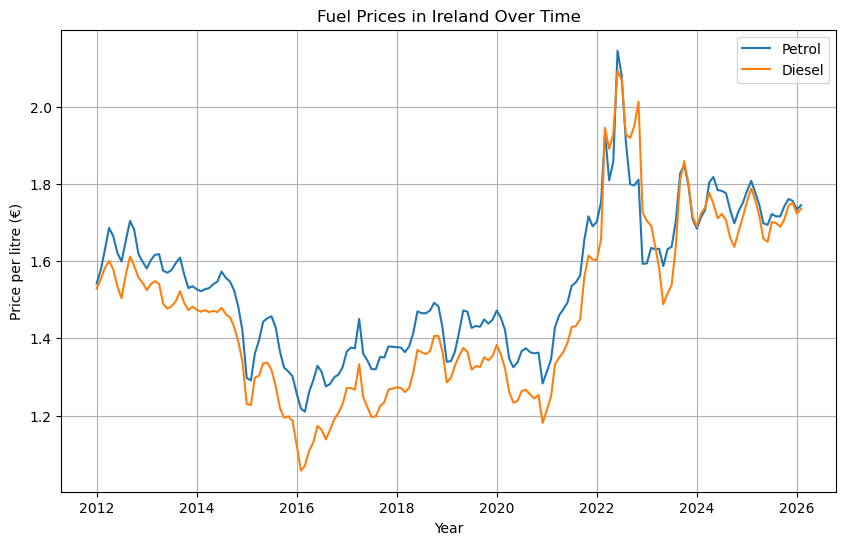

In [55]:
plt.figure(figsize=(10,6))

plt.plot(petrol['Month'], petrol['VALUE'], label='Petrol')
plt.plot(diesel['Month'], diesel['VALUE'], label='Diesel')

plt.title('Fuel Prices in Ireland Over Time')
plt.xlabel('Year')
plt.ylabel('Price per litre (€)')
plt.legend()
plt.grid()
plt.show()

In [56]:
fuel_yearly = fuel_prices.groupby('year')['VALUE'].mean().reset_index()

fuel_yearly.head()

,year,VALUE
0,2011,NaN
1,2012,1.596875
2,2013,1.543500
3,2014,1.486375
4,2015,1.314583


In [57]:
ireland_ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
5987,Ireland,Historical,EV sales,Cars,BEV,2015,Vehicles,470.0,Other
6193,Ireland,Historical,EV sales,Cars,BEV,2016,Vehicles,390.0,Other
5662,Ireland,Historical,EV sales,Cars,BEV,2017,Vehicles,620.0,Other
4987,Ireland,Historical,EV sales,Cars,BEV,2018,Vehicles,1200.0,Other
3808,Ireland,Historical,EV sales,Cars,BEV,2019,Vehicles,3400.0,Other


## Visualising relantionship between 1st and 2nd dataset (EV sales and Petrol/diesel price fluctuation)

In [59]:
ireland_ev = ireland_ev[['year', 'value']]
ireland_ev = ireland_ev.rename(columns={'value': 'ev_sales'})

In [60]:
merged_df = pd.merge(ireland_ev, fuel_yearly, on='year')

merged_df.head()

,year,ev_sales,VALUE
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


In [61]:
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

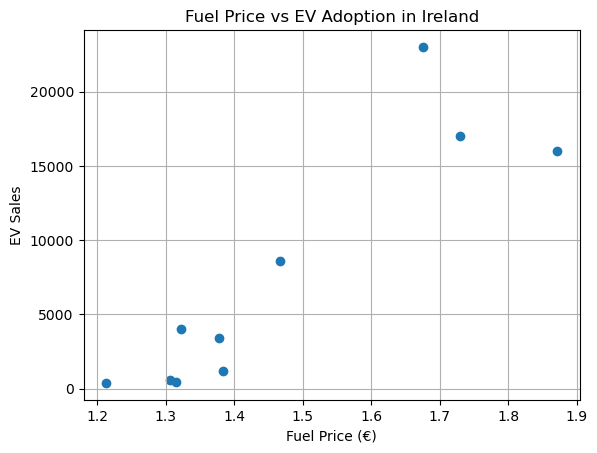

In [62]:
plt.scatter(merged_df['fuel_price'], merged_df['ev_sales'])

plt.title('Fuel Price vs EV Adoption in Ireland')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')

plt.grid()
plt.show()

## Relationship Between Fuel Prices and EV Adoption

The scatter plot above illustrates the relationship between average fuel prices and electric vehicle adoption in Ireland. A positive trend can be observed, suggesting that higher fuel prices may be associated with increased EV sales.

This supports the hypothesis that rising fuel costs act as an incentive for consumers to transition towards electric vehicles.

# Model 1- Linear Regression (Fuel --> EV Sales)

In [65]:
merged_df.head()

,year,ev_sales,fuel_price
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


In [66]:
X = merged_df[['fuel_price']]   # independent variable
y = merged_df['ev_sales']       # target variable

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 58059141.493623674
R² Score: 0.3566854128130341


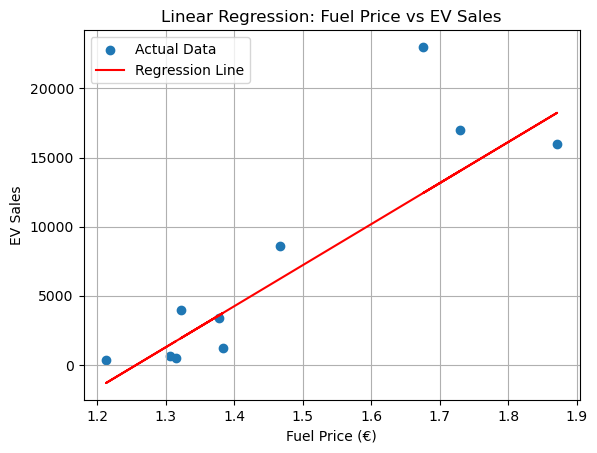

In [71]:
plt.scatter(X, y, label='Actual Data')

plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')
plt.title('Linear Regression: Fuel Price vs EV Sales')
plt.legend()
plt.grid()

plt.show()

### Model 1 Analysis (Fuel Price → EV Sales)

The linear regression model was used to analyse the relationship between fuel prices and EV sales in Ireland.

The R² score of approximately 0.35 indicates that fuel prices explain around 35% of the variation in EV sales. This suggests a moderate relationship, but also highlights that other factors influence EV adoption.

The scatter plot and regression line show a positive trend, meaning that as fuel prices increase, EV sales tend to increase. This aligns with real-world expectations, as higher fuel costs encourage consumers to switch to electric vehicles.

However, the relatively low R² value indicates that fuel prices alone are not sufficient to accurately predict EV adoption. Additional variables such as government incentives, charging infrastructure, and technological improvements are likely important factors.

This model serves as a baseline for further, more complex models.icles.

# Model 2: Multiple Linear Regression

In [126]:
# Independent variables (now 2 features)
X = merged_df[['fuel_price', 'year']]

# Target variable
y = merged_df['ev_sales']

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

In [130]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [132]:
y_pred = model.predict(X_test)

In [134]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 41965203.515416175
R² Score: 0.5350115953970507


In [136]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -2086636.0581787473
Coefficients: [17462.50068311  1023.84186857]


### Model 2 Analysis

Model 2 used both fuel price and year as independent variables to predict EV sales in Ireland.

The R² score improved from approximately 0.35 in Model 1 to approximately 0.54 in Model 2. This means the model explains around 54% of the variation in EV sales, showing that adding a time-based trend improves the prediction.

The positive coefficient for fuel price suggests that higher fuel prices are associated with higher EV sales. The positive coefficient for year also shows that EV adoption increases over time, likely due to factors such as better technology, increased public awareness, policy support, and wider availability of EVs.

However, the model is still limited because EV adoption is affected by other factors not yet included, such as charging infrastructure, government incentives, vehicle prices, and battery improvements.